# 실습 1 — nuPlan 프레임워크

nuPlan 프레임워크의 구조와 평가 과정을 분석한다. 시뮬레이션이 어떤 구성 요소로 조립되는지,
그리고 그 실행 결과가 어떤 경로를 거쳐 공식 점수가 되는지를 확인한다. 모델은 사용하지 않고
devkit 내장 규칙 기반 planner 세 개만을 사용한다.

## 학습 목표

1. 시나리오가 로그 DB 로부터 생성되는 경로를 확인한다
2. 시뮬레이션을 구성하는 네 요소를 파악하고 각각을 교체한다
3. planner 만 교체하여 점수가 달라지는 것을 확인한다

## 실습 결과물

| 산출물 | 내용 |
|---|---|
| 시나리오 객체 | DB·지도·필터를 조립하여 `AbstractScenario` 를 직접 생성한다 |
| 추종 오차 측정값 | 컨트롤러가 계획 궤적을 완전히 추종하지 못함을 수치로 확인한다 |
| 직접 구성한 시뮬레이션 | `Simulation` 루프를 조립하여 종료까지 실행한다 |
| Open-loop 점수 3 종 | 세 planner 의 공식 점수를 동일 조건에서 비교한다 |

## 전체 실습 구성에서의 위치

<img src="assets/autonomous_driving_ai_development_process.png" width="820" alt="자율주행 AI 개발 절차">

<sub>출처: [nuPlan (nuScenes.org)](https://www.nuscenes.org/nuplan)</sub>

위 네 단계 중 1 단계 **Train ML planner** 는 본 저장소의 범위 밖이며, 사전 학습된 체크포인트
(`data/model/`)를 사용한다. 나머지 세 단계를 수행하는 도구가 nuPlan 프레임워크이고, 실습 1 과 2 가
이 구간을 다룬다.

- **실습 1(본 노트북)** — 2 단계 *Simulate planner & agents* 의 구조
- **실습 2** — 해당 planner 위치에 ML 모델을 장착하고 3·4 단계로 평가
- **실습 3** — MPC 를 이용한 궤적 후처리

```
 실습 0            실습 1               실습 2                실습 3
 환경 구성      →  nuPlan 프레임워크  →  ML planner 평가    →  MPC refinement
 데이터 배치        구성 요소와 교체      Open-loop·Closed-loop  궤적 후처리와 비교
```

## 진행 순서

| 절 | 내용 | 방식 |
|---|---|---|
| 0 | 준비 — 경로·환경변수·커널 확인 | |
| 1 | 프레임워크 개관 — Closed-loop 한 스텝의 구조 | 문서 |
| 2 | 시나리오의 생성 경로 — DB → 필터 → `AbstractScenario` | API |
| 3 | 시나리오의 구성 요소 — ego·주변 물체·지도·expert 궤적 | API |
| 4 | 컨트롤러 — 추종 오차 측정 | API |
| 5 | 시뮬레이션 루프 직접 구성 및 실행 | API |
| 6 | planner 교체 — 시나리오 하나로 세 planner 비교 | config |
| 7 | 챌린지 프리셋의 구조 — Open-loop 와 Closed-loop 대비 | config |
| 8 | 정식 Open-loop 평가 — 시나리오 5 개 | config |
| 9 | 정리 | |

**2~5 절은 객체를 직접 생성**하여 구조를 확인하고, **6~8 절은 동일한 구성을 Hydra 설정으로**
교체하며 결과를 관찰한다. 같은 대상을 서로 다른 층위에서 다루는 것이다.

- **커널은 `E2E Refinement`** 여야 한다. 실습 0 과 달리 커널 내에서 devkit 을 직접 import 한다.
  커널 등록은 README 의 「준비」에서 수행하였다.
- 소요 시간은 1~2 시간이며, 시뮬레이션을 6 회 실행하는 6·8 절이 대부분을 차지한다.


## 0. 준비

노트북이 devkit 을 사용할 수 있도록 경로와 환경변수를 설정하고, 커널이 실습 환경인지 확인한다.

devkit 의 yaml 은 `${oc.env:NUPLAN_DATA_ROOT}` 와 같이 환경변수를 참조하므로, **devkit 을
import 하기 전에** `bootstrap()` 으로 데이터·지도·결과 경로를 설정해야 한다.


In [1]:
# 저장소 루트를 찾고 헬퍼를 로드한 뒤, devkit 이 참조할 환경변수를 설정한다.
import sys, pathlib

NB_DIR = pathlib.Path.cwd()
REPO_ROOT = NB_DIR if (NB_DIR / "run_simulation.py").exists() else NB_DIR.parent
assert (REPO_ROOT / "run_simulation.py").exists(), f"저장소 루트를 찾지 못했습니다: {NB_DIR}"

helper = next(REPO_ROOT.glob("practice/**/_practice1_helper.py"))
sys.path.insert(0, str(helper.parent))

# 헬퍼가 수정되면 커널이 캐시한 옛 모듈을 계속 쓴다. 이 셀을 다시 실행하면
# 최신 내용을 읽도록 reload 를 거친다.
import importlib
import _practice1_helper
importlib.reload(_practice1_helper)
from _practice1_helper import *          # noqa: F401,F403

REPO_ROOT = bootstrap()                   # 환경변수 설정 + sys.path 에 저장소 루트 등록


REPO_ROOT        : /home/user/E2E_Refinement_Practice
NUPLAN_DATA_ROOT : /home/user/E2E_Refinement_Practice/data


In [2]:
# 커널 확인 — devkit 을 직접 import 하므로 실습 환경이어야 한다.
import importlib.util

section("커널 확인")
print("python :", sys.executable)
missing = [m for m in ("nuplan", "shapely", "geopandas", "hydra", "pandas", "matplotlib")
           if importlib.util.find_spec(m) is None]
if missing:
    print("\n⚠ 커널이 실습 환경이 아닙니다. 확인되지 않은 패키지:", missing)
    print("  Kernel > Change Kernel 에서 'E2E Refinement' 를 선택하십시오.")
    print("  커널 목록에 없으면 README 의 「준비」 2 절에 따라 등록하십시오.")
else:
    import nuplan
    print("devkit :", nuplan.__file__)
    print("\n✅ devkit 경로가 본 저장소 내부이면 준비가 완료된 것이다.")


  커널 확인
python : /home/user/miniconda3/envs/e2e_refinement/bin/python
devkit : /home/user/E2E_Refinement_Practice/nuplan/__init__.py

✅ devkit 경로가 본 저장소 내부이면 준비가 완료된 것이다.


## 1. 프레임워크 개관

본 절에서 확인할 것은 두 가지이다. **Closed-loop 한 스텝의 구조**와 **교체 가능한 구성 요소**이다.

<table>
<tr>
<td width="62%" valign="top"><img src="assets/nuplan_framework_architecture.png" width="100%" alt="nuPlan 프레임워크 구조"></td>
<td width="38%" valign="top"><img src="assets/simulation_scene.png" width="100%" alt="시뮬레이션 한 스텝의 장면"></td>
</tr>
<tr>
<td align="center"><sub>프레임워크 구조 · 출처: <a href="https://www.nuscenes.org/nuplan">nuPlan (nuScenes.org)</a></sub></td>
<td align="center"><sub>한 스텝의 장면 — 3 절에서 직접 그린다</sub></td>
</tr>
</table>

왼쪽이 프레임워크의 구성, 오른쪽은 그 구성 요소가 한 스텝에서 실제로 그려진 모습이다.

| 화면 | 의미 |
|---|---|
| 회색 | 차선 |
| 하늘색 | 주행해야 할 경로 (roadblock) |
| 주황 상자 | 자차 |
| 파란 상자 | 주변 차량 |
| 상자에서 뻗은 선 | 각 객체의 궤적 |
| 자홍 → 노랑 선 | planner 가 계획한 자차 궤적 |
| 중심선 점선 색 | 그 차선의 신호등 상태 |

## 한 스텝의 구조

```
planner_input = simulation.get_planner_input()      # ① 현재 상태를 planner 에 전달
trajectory    = planner.compute_trajectory(input)   # ② planner 가 궤적을 생성
simulation.propagate(trajectory)                    # ③ 그 궤적으로 다음 상태를 결정
```

③ 이 **Closed-loop** 를 형성한다. planner 가 생성한 궤적이 다음 스텝의 입력을 변화시키므로, 한 번
이탈이 발생하면 이탈한 상태에서 다시 계획을 수립해야 한다. 로그를 그대로 재생하는 Open-loop 와
구분되는 지점이다.

## 교체 가능한 네 개의 구성 요소

| 구성 요소 | Hydra 그룹 | 역할 | 예 |
|---|---|---|---|
| planner | `planner=` | 궤적 생성 | `simple_planner`, `idm_planner`, `refinement_planner` |
| ego_controller | `ego_controller=` | 궤적 → 실제 ego 상태 | `two_stage_controller`, `perfect_tracking_controller`, `log_play_back_controller` |
| observation | `observation=` | 주변 물체의 거동 | `box_observation`(로그 재생), `idm_agents_observation`(반응) |
| simulation_time_controller | `simulation_time_controller=` | 구간과 스텝 수 | `step_simulation_time_controller` |

각 구성 요소의 선택과 생성은 설정 관리 라이브러리 [Hydra](https://hydra.cc) 가 담당한다. yaml 한 장이
클래스 경로(`_target_`)와 생성자 인자를 기술하며, 실행 시 `planner=idm_planner` 와 같은 한 줄로 그
yaml 을 교체하면 해당 구성 요소의 구현체가 바뀐다. 따라서 위 표의 "Hydra 그룹" 은 곧 **교체 단위**를
의미한다.

> **`SimulationSetup` 에는 planner 가 포함되지 않는다.** 위 네 요소 중 planner 를 제외한 세 개와
> 시나리오만 포함된다. planner 는 시뮬레이터 외부에서 궤적을 공급하는 주체이며, 양자를 결합하여
> 루프를 수행하는 것은 `SimulationRunner` 이다. 이 구분이 실습 2 에서 planner 를 장착할 위치를
> 결정한다.

구조도의 명칭과 Hydra 그룹명이 일대일로 대응하지는 않는다는 점에 유의한다.

| 그림 | Hydra 그룹 | 비고 |
|---|---|---|
| Planner | `planner=` | 동일 |
| Controller | `ego_controller=` | 그림의 Perfect Control / Kinematic Model 이 이 그룹의 하위 항목이다 |
| Observations, Agents | `observation=` | 두 블록이 하나의 그룹으로 통합되어 있다. 본 실습은 인지 결과가 주어진 상태에서 시작하므로 Raw Sensors / Perception 경로는 사용하지 않는다 |
| Open Loop / Closed Loop | `+simulation=` 프리셋 | 7 절 |

구조도 우측의 **Metrics** 는 6·8 절에서 최종 점수로 확인한다. 실습 2 는 같은 Metrics 를 Open-loop 와
Closed-loop 양쪽에 적용한다.

<details>
<summary><b>설정 파일의 위치</b> — 이후 진행에 필수적인 내용은 아니며, 필요할 때 참고한다.</summary>

설정은 **저장소**와 **devkit** 두 갈래에 나뉘어 있다.

| 위치 | 들어 있는 것 |
|---|---|
| `config/` | **실습이 추가한 것** — `planner/refinement_planner.yaml`, `planner/model_adapter/`, `scenario_filter/`, 진입점 `default_simulation.yaml` |
| `nuplan/planning/script/config/simulation/` | **시뮬레이션 구성 요소** — `planner/`, `ego_controller/`(+`tracker/`, `motion_model/`), `observation/`, `simulation_time_controller/`, `callback/`, `metric_aggregator/` |
| `nuplan/planning/script/config/common/` | 공통 — `scenario_builder/`, `scenario_filter/`, `simulation_metric/`, `worker/` |
| `nuplan/planning/script/experiments/simulation/` | 챌린지 프리셋 (7 절) |

즉 자차 컨트롤러·주변 객체·시간 진행처럼 **시뮬레이션을 이루는 요소의 설정은 전부 devkit 안에**
있고, 저장소의 `config/` 에는 실습이 더한 planner 와 시나리오 필터만 있다.

두 곳이 하나처럼 동작하는 것은 `config/default_simulation.yaml` 이 devkit 경로를 Hydra 의
**searchpath** 에 등록해 두었기 때문이다.

```yaml
hydra:
  searchpath:
    - pkg://nuplan.planning.script.config.common
    - pkg://nuplan.planning.script.config.simulation
    - pkg://nuplan.planning.script.experiments
```

그래서 `planner` 그룹에는 두 곳의 yaml 이 함께 들어온다. `planner=simple_planner` 는 devkit 의 것을,
`planner=refinement_planner` 는 저장소의 것을 선택하며, 사용하는 입장에서는 구분되지 않는다.

</details>

아래 셀에서 devkit 의 실제 루프를 확인한다. 위 세 줄이 콜백 사이에 그대로 존재한다.


In [3]:
# devkit 이 실제로 도는 시뮬레이션 루프의 소스를 그대로 출력한다.
import inspect
from nuplan.planning.simulation.runner.simulations_runner import SimulationRunner

src = inspect.getsource(SimulationRunner.run).splitlines()
print("\n".join(src[26:48]))          # while 루프 부분



        while self.simulation.is_simulation_running():
            # Execute specific callback
            self.simulation.callback.on_step_start(self.simulation.setup, self.planner)

            # Perform step
            planner_input = self._simulation.get_planner_input()
            logger.debug("Simulation iterations: %s" % planner_input.iteration.index)

            # Execute specific callback
            self._simulation.callback.on_planner_start(self.simulation.setup, self.planner)

            # Plan path based on all planner's inputs
            trajectory = self.planner.compute_trajectory(planner_input)

            # Propagate simulation based on planner trajectory
            self._simulation.callback.on_planner_end(self.simulation.setup, self.planner, trajectory)
            self.simulation.propagate(trajectory)

            # Execute specific callback
            self.simulation.callback.on_step_end(self.simulation.setup, self.planner, self.simulation.history.last())



**확인 사항** — `while self.simulation.is_simulation_running():` 내부에 `get_planner_input` →
`compute_trajectory` → `propagate` 가 순서대로 위치하며, 나머지는 전부 `callback` 이다.
즉 루프의 본체는 위 세 줄이 전부이다.


## 2. 시나리오의 생성 경로

`scenario_filter=practice_scenarios` 한 줄이 수행하는 작업을 단계별로 확인한다. 경로는 다음과 같다.

```
data/db/test/*.db  →  discover_log_dbs  →  NuPlanScenarioBuilder
                                              +  ScenarioFilter        →  [AbstractScenario, ...]
```

### (a) 로그 · 토큰 · 시나리오

nuPlan 의 주행 로그는 DB 파일 하나(`*.db`)이며, 주행 중 **20 Hz(0.05 s) 주기로 자차 상태와
주변 객체의 상태를 기록**한 것이다. 본 실습에서 다루는 개념은 다음 세 가지이다.

| 개념 | 정의 | 예 |
|---|---|---|
| **log** | 하나의 주행 기록. DB 파일 하나에 대응하며 수 분 분량이다 | `2021.05.25.14.16.10_veh-35_01100_01664` |
| **token** | 로그 내 특정 시각의 한 프레임을 지시하는 식별자. 시나리오의 기준 시각이 된다 | `56cdd36746c85788` |
| **scenario** | token 을 기준으로 로그에서 절단한 구간. 유형(`scenario_type`)이 부여된다 | `high_magnitude_speed`, 15 s |

<img src="assets/scenario_sample.gif" width="820" alt="nuPlan 시나리오 유형 예시">

<sub>출처: [nuPlan (nuScenes.org)](https://www.nuscenes.org/nuplan)</sub>

위는 시나리오 유형의 예시이다. 좌회전·차선 변경·보행자 횡단과 같이 **판단이 필요한 상황**이
유형으로 정의되어 있으며, nuPlan 은 이러한 유형을 70 여 종 제공한다. 실습에 사용할
`practice_scenarios` 의 5 개 시나리오도 각각 하나의 유형에 속한다.

세 개념의 관계는 다음과 같다. **하나의 log 에 다수의 token 이 존재하며, token 하나가 시나리오
하나에 대응한다.** 시나리오의 길이와 샘플링 주기는 로그에 기록된 값이 아니라 (b) 의
`ScenarioMapping` 이 유형별로 정의하는 값이다.

`config/scenario_filter/*.yaml` 은 이 중 **log 와 token 을 직접 지정**한다. 아래에서 실습에
사용할 필터의 내용과 대상 DB 를 확인한다.


In [4]:
# 실습에 사용할 로그(DB) 목록과, 그중 무엇을 고를지 적어 둔 필터 yaml 을 확인한다.
section("실습에 사용할 로그 — data/db/test")
DBS = sorted((REPO_ROOT / "data/db/test").glob("*.db"))
for db in DBS:
    print(f"  {db.name:45s} {db.stat().st_size / 1e6:6.0f} MB")
print(f"\n  총 {len(DBS)} 개")

section("시나리오 필터 — config/scenario_filter/practice_scenarios.yaml")
print((REPO_ROOT / "config/scenario_filter/practice_scenarios.yaml").read_text())


  실습에 사용할 로그 — data/db/test
  2021.05.25.12.40.06_veh-47_05213_05515.db        210 MB
  2021.05.25.14.16.10_veh-35_01100_01664.db        269 MB
  2021.05.25.17.38.43_veh-27_00048_00406.db        225 MB
  2021.06.28.21.23.50_veh-47_04712_05316.db        349 MB

  총 4 개
  시나리오 필터 — config/scenario_filter/practice_scenarios.yaml
_target_: nuplan.planning.scenario_builder.scenario_filter.ScenarioFilter
_convert_: 'all'

scenario_types: null
# 특정 시나리오
scenario_tokens:
  - "56cdd36746c85788"
  - "bc962c4b185859a6"
  - "f9ac8947d2c55c1b"
  - "d13124fa683654b4"
  - "a112ea9f3d2b5d5b"

# 시나리오가 생성되는 주행 기록 [하나의 주행기록에 여러개의 시뮬레이션 존재 가능]
log_names:
  - 2021.05.25.12.40.06_veh-47_05213_05515
  - 2021.05.25.14.16.10_veh-35_01100_01664
  - 2021.05.25.17.38.43_veh-27_00048_00406
  - 2021.06.28.21.23.50_veh-47_04712_05316
map_names: null

num_scenarios_per_type: null
limit_total_scenarios: null
timestamp_threshold_s: 15
ego_displacement_minimum_m: null
ego_start_speed_threshold: null
ego_stop_speed_thres

**확인 사항** — 필터에 기재된 `log_names` 3 개가 위 DB 파일 3 개와 일치하고, `scenario_tokens`
5 개가 네 개의 로그에 분포한다. 시나리오 생성에 필요한 정보는 이 두 가지뿐이다.

### (b) 시나리오 초기화

Hydra 를 경유하지 않고 시나리오를 직접 생성한다. 필요한 것은 세 가지이다.

| 구성 | 정의하는 것 |
|---|---|
| `NuPlanScenarioBuilder` | 어느 DB 와 지도를 읽을 것인가 |
| `ScenarioMapping` | 유형별로 시나리오를 몇 초 길이, 몇 Hz 로 자를 것인가 |
| `ScenarioFilter` | 그중 어떤 것을 고를 것인가 |

`ScenarioMapping` 은 devkit 의 `nuplan_scenario_mapping.yaml` 을 그대로 사용한다. 이를 지정해야
로그의 20 Hz 기록이 공식 챌린지와 동일한 조건인 **15 초 · 10 Hz(150 스텝)** 로 절단·서브샘플링된다.


In [5]:
# 시나리오 초기화 — 빌더 · 매핑 · 필터를 조립하여 AbstractScenario 목록을 얻는다.
from nuplan.planning.scenario_builder.nuplan_db.nuplan_scenario_builder import NuPlanScenarioBuilder
from nuplan.planning.utils.multithreading.worker_sequential import Sequential

# [1] 유형별 시나리오 길이와 샘플링 주기 정의 (devkit yaml 을 그대로 읽는다)
scenario_mapping = load_scenario_mapping(REPO_ROOT)

# [2] 빌더 — 읽어 들일 DB 와 지도의 위치를 지정한다
builder = NuPlanScenarioBuilder(
    data_root=str(REPO_ROOT / "data/db/test"),
    map_root=str(REPO_ROOT / "data/maps"),
    sensor_root=str(REPO_ROOT / "data/sensor_blobs"),
    db_files=None,                      # None 이면 data_root 아래의 DB 를 모두 사용한다
    map_version="nuplan-maps-v1.0",
    scenario_mapping=scenario_mapping,
)

# [3] 필터 — 어떤 시나리오를 고를지 지정한다 (지정하지 않은 필드는 비활성)
scenario_filter = make_filter(
    scenario_tokens=["56cdd36746c85788"],                        # 기준 시각(프레임)
    log_names=["2021.05.25.14.16.10_veh-35_01100_01664"],        # 대상 주행 기록
    timestamp_threshold_s=15,                                    # 15 초 미만 시나리오는 제외
)

# [4] 생성 — 조건에 맞는 시나리오를 실제로 만든다 (Sequential = 단일 프로세스)
scenarios = builder.get_scenarios(scenario_filter, Sequential())
display(scenario_table(scenarios))


,idx,token,scenario_type,log_name,iterations,dt
0,0,56cdd36746c85788,high_magnitude_speed,2021.05.25.14.16.10_veh-35_0,150,0.1


**확인 사항** — `iterations` 가 150, `dt` 가 0.1 s 이다. 로그 자체는 20 Hz(0.05 s)로 기록되어
있으나 `ScenarioMapping` 이 이를 15 초 · 10 Hz 로 정리한 결과이다.

필터에 지정할 수 있는 항목은 `scenario_tokens` · `log_names` 외에도 `scenario_types`(유형으로 선택),
`limit_total_scenarios`(개수 제한) 등이 있다. 다만 `config/scenario_filter/*.yaml` 은 유형이 아니라
**토큰을 직접 명시**한다. 유형으로 선택하면 실행할 때마다 다른 시나리오가 선택되어 결과를 비교할
수 없기 때문이다.

### (c) Hydra 설정으로 시나리오 생성

같은 작업을 Hydra 설정으로 수행한다. `run_simulation.py` 를 실행할 때 내부에서 일어나는 것이
이 과정이며, (b) 에서 인자로 직접 넘긴 값들이 yaml 에서 조립된다는 점만 다르다.

두 빌더 함수는 전달받는 노드가 다르다.

| 함수 | 전달 대상 |
|---|---|
| `build_scenario_builder(cfg)` | **전체 cfg** (`cfg.scenario_builder` 를 내부에서 참조) |
| `build_scenario_filter(cfg.scenario_filter)` | **하위 노드** |


In [6]:
# 위 [1]~[4] 를 Hydra 설정으로 동일하게 수행한다 — run_simulation.py 가 하는 방식이다.
from hydra import compose, initialize_config_dir
from hydra.core.global_hydra import GlobalHydra
from nuplan.planning.script.builders.scenario_building_builder import build_scenario_builder
from nuplan.planning.script.builders.scenario_filter_builder import build_scenario_filter

GlobalHydra.instance().clear()            # 동일 프로세스에서 두 번 이상 호출하려면 필요하다
with initialize_config_dir(config_dir=str(REPO_ROOT / "config")):
    cfg = compose(config_name="default_simulation", overrides=[
        "+simulation=open_loop_boxes",
        "planner=simple_planner",
        "scenario_builder=nuplan",
        "scenario_filter=practice_scenarios",
        "worker=sequential",
    ])

hydra_builder = build_scenario_builder(cfg)                    # 전체 cfg
hydra_filter = build_scenario_filter(cfg.scenario_filter)      # 하위 노드
hydra_scenarios = hydra_builder.get_scenarios(hydra_filter, Sequential())
display(scenario_table(hydra_scenarios))


,idx,token,scenario_type,log_name,iterations,dt
0,0,56cdd36746c85788,high_magnitude_speed,2021.05.25.14.16.10_veh-35_0,150,0.1
1,1,a112ea9f3d2b5d5b,stationary_in_traffic,2021.06.28.21.23.50_veh-47_0,150,0.1
2,2,bc962c4b185859a6,waiting_for_pedestrian_to_cross,2021.05.25.12.40.06_veh-47_0,150,0.1
3,3,d13124fa683654b4,following_lane_with_lead,2021.06.28.21.23.50_veh-47_0,150,0.1
4,4,f9ac8947d2c55c1b,traversing_pickup_dropoff,2021.05.25.17.38.43_veh-27_0,150,0.1


**확인 사항** — `practice_scenarios` 에 기재된 토큰 5 개가 그대로 5 개의 시나리오로 생성되었다.
(b) 에서 인자로 지정했던 것과 동일한 결과이다.


## 3. 시나리오의 구성 요소

생성한 시나리오가 어떤 정보를 담고 있는지 조회한다. 시뮬레이션이 사용하는 인터페이스는
아래 다섯 개이다.

| 메서드 | 조회하는 것 |
|---|---|
| `get_ego_state_at_iteration(i)` | 해당 시각의 자차 상태 |
| `get_tracked_objects_at_iteration(i)` | 해당 시각의 주변 물체 |
| `get_route_roadblock_ids()` | 주행해야 할 도로 구간 id |
| `get_mission_goal()` | 최종 목표 pose |
| `get_expert_ego_trajectory()` | 실제 주행 궤적 |


In [7]:
# 생성된 시나리오의 기본 정보와 초기 시각의 상태를 확인한다.
scenario = scenarios[0]

section("시나리오 기본 정보")
print("token          :", scenario.token)
print("log_name       :", scenario.log_name)
print("scenario_type  :", scenario.scenario_type)
print("database_interval:", scenario.database_interval, "s")
print("iterations     :", scenario.get_number_of_iterations(),
      f"({scenario.get_number_of_iterations() * scenario.database_interval:.0f} s)")

section("초기 시각(iteration 0)의 상태")
ego0 = scenario.get_ego_state_at_iteration(0)
print("ego rear_axle  :", ego0.rear_axle)
print("speed          :", round(ego0.dynamic_car_state.speed, 2), "m/s")
print("주변 물체       :", len(scenario.get_tracked_objects_at_iteration(0).tracked_objects), "개")
print("mission goal   :", scenario.get_mission_goal())


  시나리오 기본 정보
token          : 56cdd36746c85788
log_name       : 2021.05.25.14.16.10_veh-35_01100_01664
scenario_type  : high_magnitude_speed
database_interval: 0.1 s
iterations     : 150 (15 s)
  초기 시각(iteration 0)의 상태
ego rear_axle  : StateSE2(x=664457.946549217, y=3998095.010708662, heading=1.5483467591502396)
speed          : 13.9 m/s
주변 물체       : 161 개
mission goal   : StateSE2(x=664473.1344582066, y=3998763.144912442, heading=1.373102162360186)


### 주행 경로를 지도상의 기하로 변환

`get_route_roadblock_ids()` 가 반환하는 것은 id 문자열이므로, 실제 좌표를 얻으려면 `map_api` 를
조회해야 한다. roadblock → 내부 차선(`interior_edges`) → 차선 중심선(`baseline_path.discrete_path`)
순으로 접근한다.

> 최초 지도 접근 시 수십 초가 소요될 수 있다(이후 캐시된다).
> 일부 지역의 지도가 없다는 메시지가 출력되는 것은 정상이다.


In [8]:
# 주행 경로 id 를 지도 객체로 변환하여 차선 중심선의 기하 정보를 얻는다.
from nuplan.common.maps.maps_datatypes import SemanticMapLayer

section("주행 경로 (roadblock id)")
route = scenario.get_route_roadblock_ids()
print("roadblock", len(route), "개:", route[:5], "...")

obj = scenario.map_api.get_map_object(route[0], SemanticMapLayer.ROADBLOCK)
if obj is None:                      # 교차로 내부는 ROADBLOCK_CONNECTOR 이다
    obj = scenario.map_api.get_map_object(route[0], SemanticMapLayer.ROADBLOCK_CONNECTOR)

section("첫 roadblock 의 차선 기하")
lane = obj.interior_edges[0]
center = lane.baseline_path.discrete_path
print("첫 roadblock 의 차선 수:", len(obj.interior_edges))
print("차선 중심선 pose 수    :", len(center), "| 시작:", center[0])


  주행 경로 (roadblock id)


Map location 'us-ma-boston' is not available under map_root '/home/user/E2E_Refinement_Practice/data/maps' — skipping. (/home/user/E2E_Refinement_Practice/data/maps/us-ma-boston/9.12.1817/map.gpkg: No such file or directory)
Map location 'us-pa-pittsburgh-hazelwood' is not available under map_root '/home/user/E2E_Refinement_Practice/data/maps' — skipping. (/home/user/E2E_Refinement_Practice/data/maps/us-pa-pittsburgh-hazelwood/9.17.1937/map.gpkg: No such file or directory)


roadblock 21 개: ['46945', '66456', '65524', '66790', '65623'] ...
  첫 roadblock 의 차선 기하
첫 roadblock 의 차선 수: 4
차선 중심선 pose 수    : 214 | 시작: StateSE2(x=664455.4889611017, y=3997896.1594378427, heading=1.5943897528173785)


### 시나리오 시각화

지금까지 조회한 정보를 한 장의 그림으로 확인한다. 시나리오의 처음·중간·끝 세 시각을 렌더링하여
자차가 어떤 상황에서 출발해 어디로 향하는지 파악한다.

회색은 차선, 파란 상자는 주변 물체, 초록 점선은 expert 궤적이다.


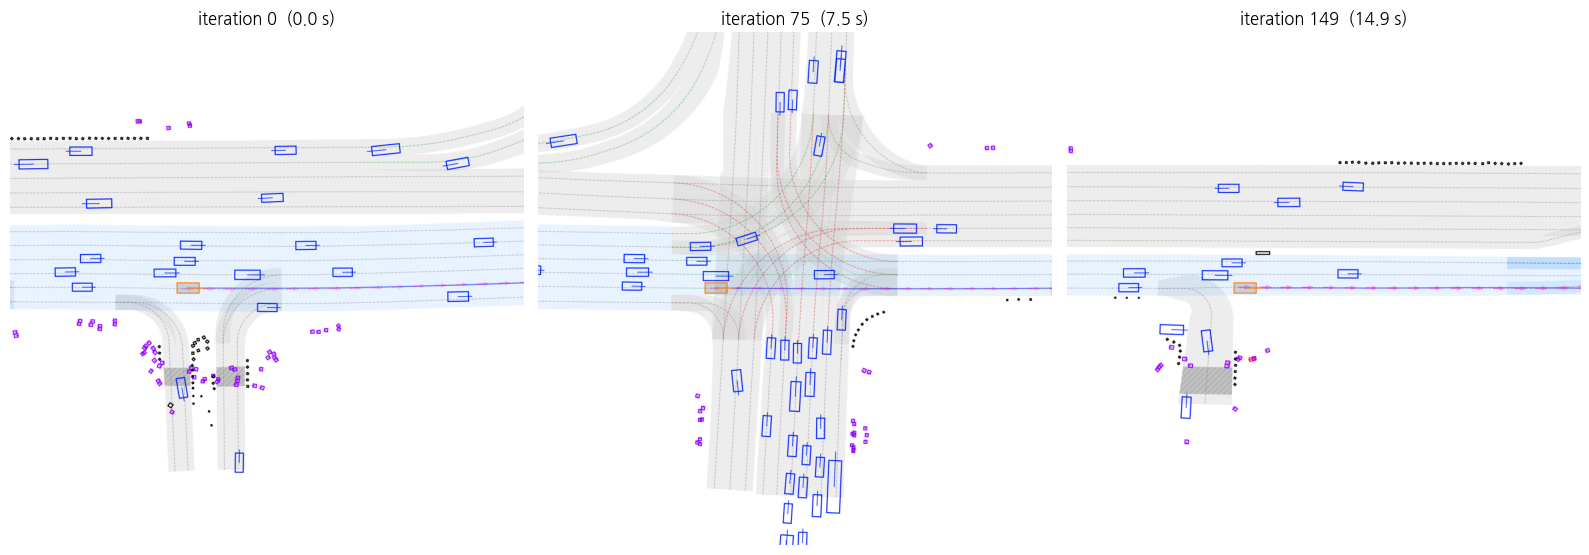

In [9]:
# 시나리오의 처음·중간·끝 시각을 렌더링하여 나란히 표시한다.
import matplotlib.pyplot as plt
from src.feature_builders.nuplan_scenario_render import NuplanScenarioRender

N = scenario.get_number_of_iterations()
fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
for ax, it in zip(axes, [0, N // 2, N - 1]):
    ax.imshow(NuplanScenarioRender().render_from_scenario(scenario, iteration=it, return_image=True))
    ax.set_title(f"iteration {it}  ({it * scenario.database_interval:.1f} s)")
    ax.axis("off")
plt.tight_layout()
plt.show()


**확인 사항** — 화면은 항상 자차를 중심으로 회전되어 있다. 한 장면을 자세히 보기에는 편리하나
서로 다른 주행 결과를 같은 축에 겹쳐 볼 수는 없다. 5 절에서는 궤적을 global frame 으로 도시한다.


## 4. 제어기 분석

planner 가 생성한 궤적은 **목표값**이며, 자차가 실제로 어떻게 움직일지는 `ego_controller` 가
결정한다. 본 절에서는 그 둘의 차이, 즉 **추종 오차를 직접 측정**한다.

기본값인 `TwoStageController` 는 두 단계로 구성된다.

```
1단계  tracker       계획 궤적 + 현재 자차 상태  ──▶  LQR                ──▶  [가속도, 조향각속도]
2단계  motion_model  현재 자차 상태 + [가속도, 조향각속도]  ──▶  Kinematic bicycle  ──▶  다음 자차 상태
```

두 단계 각각에서 **추종 오차**가 발생한다.

**1단계 — LQR 은 주어진 reference 를 완벽하게 따라가지 않는다.**

- LQR 의 해는 상태 오차 가중치 `Q` 와 입력 가중치 `R` 의 **절충**이다. 오차를 0 으로 만드는 입력이
  존재하더라도 입력 비용 때문에 그것을 선택하지 않으므로, 정상 상태에서도 잔류 오차가 남는다.
- 종방향과 횡방향을 분리하여 각각 **선형 모델로 근사**한다. 종방향은 "가속도를 `tracking_horizon`
  동안 일정하게 유지한다"는 가정 위에서 풀고(`v_N = v_0 + N·dt·a`), 횡방향은 곡률 프로파일을
  기준으로 선형화한다. 실제 거동의 비선형성은 이 근사에 담기지 않는다.
- 한 번에 산출하는 것은 **한 스텝 분의 입력 한 쌍**이며, 다음 스텝에서 상태가 예측과 달라지면
  다시 푼다. 그 차이가 매 스텝의 오차로 나타난다.

**2단계 — Kinematic bicycle 모델이 실제 차량과 다르다.**

- **오일러 적분**으로 한 스텝(0.1 s)을 전진시킨다(`x + ẋ·dt`). 곡선 구간처럼 상태가 빠르게 변하는
  구간일수록 이산화 오차가 커진다.
- **횡방향 속도를 항상 0 으로** 둔다. 타이어 슬립이 없다는 가정이므로, 슬립이 포함된 실제 주행
  기록은 이 모델로 정확히 재현되지 않는다.
- 조향각은 `±60°` 로 제한된다. 기구학적으로 실현할 수 없는 궤적은 애초에 재현되지 않는다.

측정 방법은 다음과 같다. **expert 궤적을 그대로 추종시킨다.** 실제 주행 기록이므로 물리적
실현 가능성이 보장되며, 그럼에도 오차가 잔존한다면 이는 전적으로 컨트롤러에 기인한 것이다.


#### 빈칸 ① — 추종 오차의 분해

전역 좌표의 오차 `(dx, dy)` 를 reference 의 진행 방향 `h` 기준으로 회전시켜
**종방향·횡방향**으로 나눈다. 전체 크기만 보면 어느 파라미터가 무엇을 바꾸는지 구분되지 않는다.

$$
e_{lon} = dx\cos h + dy\sin h, \qquad
e_{lat} = -dx\sin h + dy\cos h, \qquad
e_{tot} = \sqrt{dx^2 + dy^2}
$$

`e_lon > 0` 이면 reference 보다 **앞서** 있고, `e_lat > 0` 이면 **왼쪽**으로 벗어나 있다.
`e_tot` 는 분해와 무관한 원래 거리이므로 $e_{lon}^2 + e_{lat}^2 = e_{tot}^2$ 가 성립한다.


In [12]:
import numpy as np

def decompose_error(dx, dy, h):
    """전역 오차 (dx, dy) 를 진행 방향 h 기준 (종방향, 횡방향, 전체) 로 분해한다."""
    # 예시 — 아래 둘을 같은 방식으로 따라 쓴다.
    e_lon = dx * np.cos(h) + dy * np.sin(h)

    # [TODO ①] 목적: 오차의 '옆으로 벗어난' 성분만 떼어낸다. q_lateral 을 바꿨을 때
    #                무엇이 변했는지 보려면 종방향과 섞이면 안 된다.
    #          채울 것: 횡방향 성분 e_lat  (양수면 reference 기준 왼쪽)
    #          수식: e_lat = -dx*sin(h) + dy*cos(h)
    e_lat = -dx*np.sin(h) + dy * np.cos(h)

    # [TODO ②] 목적: 분해가 크기를 바꾸지 않았음을 확인할 기준값을 만든다.
    #                e_lon^2 + e_lat^2 == e_tot^2 이 성립해야 한다.
    #          채울 것: 분해와 무관한 원래 거리 e_tot
    #          수식: e_tot = sqrt(dx^2 + dy^2)      (np.hypot 을 써도 된다)
    e_tot = np.sqrt(dx*dx+dy*dy)

    return e_lon, e_lat, e_tot


check_decompose_error(decompose_error)


✅ decompose_error — 5개 검사 통과


True

In [13]:
# expert 궤적을 컨트롤러에 입력하여 스텝별 추종 오차를 측정하는 함수를 정의한다.
# 오차는 reference 의 진행 방향을 기준으로 **종방향·횡방향으로 분해**한다.
# 전체 크기만 보면 어느 파라미터가 무엇을 바꾸는지 구분되지 않는다.
import numpy as np
from nuplan.planning.simulation.controller.motion_model.kinematic_bicycle import KinematicBicycleModel
from nuplan.planning.simulation.controller.tracker.lqr import LQRTracker
from nuplan.planning.simulation.controller.two_stage_controller import TwoStageController
from nuplan.planning.simulation.simulation_time_controller.simulation_iteration import SimulationIteration
from nuplan.planning.simulation.trajectory.interpolated_trajectory import InterpolatedTrajectory

expert = list(scenario.get_expert_ego_trajectory())
expert_traj = InterpolatedTrajectory(expert)
STEPS = 60


def tracking_error(**tracker_overrides):
    """expert 궤적을 추종시키고 스텝별 오차를 분해하여 돌려준다.

    반환: dict(s=진행거리[m], lon=종방향[m], lat=횡방향[m], total=|e|[m])
      lon > 0 이면 reference 보다 앞서 있고, lat > 0 이면 왼쪽으로 벗어나 있다.
    """
    params = {**LQR_DEFAULT, **tracker_overrides}
    ctrl = TwoStageController(scenario, LQRTracker(**params),
                              KinematicBicycleModel(scenario.ego_vehicle_parameters))
    lon, lat, total = [], [], []
    for i in range(STEPS):
        cur = SimulationIteration(expert[i].time_point, i)
        nxt = SimulationIteration(expert[i + 1].time_point, i + 1)
        ctrl.update_state(cur, nxt, ctrl.get_state(), expert_traj)
        s, ref = ctrl.get_state(), expert[i + 1]
        dx = s.rear_axle.x - ref.rear_axle.x
        dy = s.rear_axle.y - ref.rear_axle.y
        h = ref.rear_axle.heading                  # reference 의 진행 방향
        e_lon, e_lat, e_tot = decompose_error(dx, dy, h)
        lon.append(e_lon); lat.append(e_lat); total.append(e_tot)

    ref_xy = np.array([[e.rear_axle.x, e.rear_axle.y] for e in expert[:STEPS + 1]])
    station = np.concatenate([[0.0], np.cumsum(np.hypot(*np.diff(ref_xy, axis=0).T))])[1:]
    return dict(s=station, lon=np.array(lon), lat=np.array(lat), total=np.array(total))


# reference 자체가 어떤 상황인지 먼저 확인한다 — 어려운 구간이 아니면 횡방향 제어가 할 일이 없다.
section("reference (expert 궤적) 의 난이도")
ref_xy = np.array([[e.rear_axle.x, e.rear_axle.y] for e in expert[:STEPS + 1]])
ref_hd = np.unwrap([e.rear_axle.heading for e in expert[:STEPS + 1]])
ref_sp = np.array([e.dynamic_car_state.speed for e in expert[:STEPS + 1]])
seg = np.hypot(*np.diff(ref_xy, axis=0).T)
kappa = np.diff(ref_hd) / np.maximum(seg, 1e-6)          # 곡률 [1/m]
print(f"  구간          {STEPS * 0.1:.0f} s, {seg.sum():.1f} m")
print(f"  헤딩 총 변화  {np.degrees(ref_hd[-1] - ref_hd[0]):+.2f}°")
print(f"  곡률 최대     {np.abs(kappa).max():.5f} 1/m  (회전 반경 {1 / max(np.abs(kappa).max(), 1e-9):.0f} m)")
print(f"  속도          {ref_sp.min():.1f} ~ {ref_sp.max():.1f} m/s")
print(f"  횡가속도 최대 {(ref_sp[:-1] ** 2 * np.abs(kappa)).max():.3f} m/s²")

section("기본 LQR 파라미터의 추종 오차")
base = tracking_error()
print(f"  전체 |e|   평균 {base['total'].mean():.4f}  최대 {base['total'].max():.4f} m")
print(f"  종방향     평균 {np.abs(base['lon']).mean():.4f}  최대 {np.abs(base['lon']).max():.4f} m")
print(f"  횡방향     평균 {np.abs(base['lat']).mean():.4f}  최대 {np.abs(base['lat']).max():.4f} m")
print(f"\n  → 전체 오차의 {np.abs(base['lat']).mean() / base['total'].mean() * 100:.0f}% 만 횡방향이다.")


  reference (expert 궤적) 의 난이도
  구간          6 s, 82.1 m
  헤딩 총 변화  +2.34°
  곡률 최대     0.00104 1/m  (회전 반경 960 m)
  속도          13.7 ~ 14.0 m/s
  횡가속도 최대 0.204 m/s²
  기본 LQR 파라미터의 추종 오차
  전체 |e|   평균 0.1100  최대 0.1620 m
  종방향     평균 0.1061  최대 0.1548 m
  횡방향     평균 0.0260  최대 0.0558 m

  → 전체 오차의 24% 만 횡방향이다.


실제 주행 기록임에도 오차가 0 이 아니다. 다음 두 가지를 함께 확인한다.

1. **오차가 어느 방향인가** — reference 의 진행 방향을 기준으로 종방향과 횡방향으로 분해한다.
2. **reference 자체가 어려운 구간인가** — 곡률과 횡가속도로 판단한다. 직선에 가까운 구간이면
   횡방향 제어는 애초에 교정할 것이 없으므로, `q_lateral` 을 조정해도 전체 오차는 거의 변하지 않는다.

조정할 파라미터는 다음과 같다.

| 파라미터 | 의미 | 주로 영향을 주는 성분 |
|---|---|---|
| `q_lateral` = `[횡오차, 헤딩오차, 조향각]` | 횡방향 LQR 의 상태 가중치 | 횡방향 |
| `q_longitudinal` = `[속도오차]` | 종방향 LQR 의 상태 가중치 | 종방향 |
| `tracking_horizon` | LQR 이 앞을 보는 스텝 수 | 양쪽 |


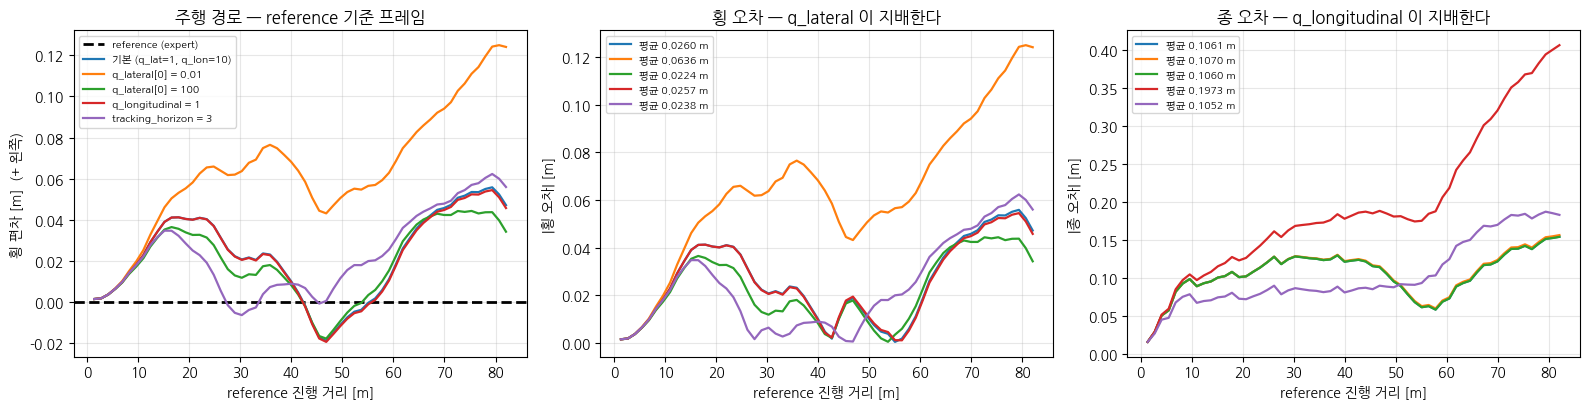

  파라미터별 오차 요약  [m]
  파라미터                               전체       종방향       횡방향
  기본 (q_lat=1, q_lon=10)         0.1100    0.1061    0.0260
  q_lateral[0] = 0.01            0.1258    0.1070    0.0636
  q_lateral[0] = 100             0.1090    0.1060    0.0224
  q_longitudinal = 1             0.1995    0.1973    0.0257
  tracking_horizon = 3           0.1085    0.1052    0.0238


In [ ]:
# 파라미터를 바꿔 가며 (1) reference 기준의 주행 경로와 (2) 오차 성분을 함께 본다.
variants = {
    "기본 (q_lat=1, q_lon=10)":      {},
    "q_lateral[0] = 0.01":           dict(q_lateral=[0.01, 10.0, 0.0]),
    "q_lateral[0] = 100":            dict(q_lateral=[100.0, 10.0, 0.0]),
    "q_longitudinal = 1":            dict(q_longitudinal=[1.0]),
    "tracking_horizon = 3":          dict(tracking_horizon=3),
}
results = {name: tracking_error(**kw) for name, kw in variants.items()}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# (1) reference 기준 프레임 — reference 는 y=0 인 수평선이 된다.
#     절대 좌표로 겹쳐 그리면 82 m 직선 위의 수 cm 차이가 보이지 않는다.
ax = axes[0]
ax.axhline(0.0, color="black", lw=2, ls="--", label="reference (expert)")
for name, r in results.items():
    ax.plot(r["s"], r["lat"], lw=1.6, label=name)
ax.set_xlabel("reference 진행 거리 [m]"); ax.set_ylabel("횡 편차 [m]  (+ 왼쪽)")
ax.set_title("주행 경로 — reference 기준 프레임")
ax.legend(fontsize=7.5); ax.grid(alpha=0.3)

# (2) 횡 오차 — q_lateral 의 효과가 드러나는 곳
ax = axes[1]
for name, r in results.items():
    ax.plot(r["s"], np.abs(r["lat"]), lw=1.6, label=f"평균 {np.abs(r['lat']).mean():.4f} m")
ax.set_xlabel("reference 진행 거리 [m]"); ax.set_ylabel("|횡 오차| [m]")
ax.set_title("횡 오차 — q_lateral 이 지배한다")
ax.legend(fontsize=7.5); ax.grid(alpha=0.3)

# (3) 종 오차 — q_longitudinal 의 효과가 드러나는 곳
ax = axes[2]
for name, r in results.items():
    ax.plot(r["s"], np.abs(r["lon"]), lw=1.6, label=f"평균 {np.abs(r['lon']).mean():.4f} m")
ax.set_xlabel("reference 진행 거리 [m]"); ax.set_ylabel("|종 오차| [m]")
ax.set_title("종 오차 — q_longitudinal 이 지배한다")
ax.legend(fontsize=7.5); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

section("파라미터별 오차 요약  [m]")
print(f"  {'파라미터':<28}{'전체':>9}{'종방향':>10}{'횡방향':>10}")
for name, r in results.items():
    print(f"  {name:<28}{r['total'].mean():9.4f}{np.abs(r['lon']).mean():10.4f}"
          f"{np.abs(r['lat']).mean():10.4f}")


비교 대상으로 **`PerfectTrackingController`** 를 확인한다. 궤적을 그대로 따르므로 오차가 0 이다.
이를 사용하면 planner 평가에서 컨트롤러의 영향이 제거되나, 동시에 **물리적으로 실현 불가능한
궤적도 그대로 실행**되므로 Closed-loop 챌린지에서는 사용하지 않는다.


In [15]:
# 비교 대상 — 궤적을 그대로 따르는 컨트롤러의 오차를 측정한다.
from nuplan.planning.simulation.controller.perfect_tracking import PerfectTrackingController

perfect = PerfectTrackingController(scenario)
errs = []
for i in range(STEPS):
    cur = SimulationIteration(expert[i].time_point, i)
    nxt = SimulationIteration(expert[i + 1].time_point, i + 1)
    perfect.update_state(cur, nxt, perfect.get_state(), expert_traj)
    s = perfect.get_state()
    errs.append(np.hypot(s.rear_axle.x - expert[i + 1].rear_axle.x,
                         s.rear_axle.y - expert[i + 1].rear_axle.y))
print(f"PerfectTracking — 평균 {np.mean(errs):.6f} m")


PerfectTracking — 평균 0.000000 m


### 실습에서 사용하는 컨트롤러

`ego_controller` 그룹에는 세 가지 구현이 있으며, 본 실습에서 세 가지를 모두 사용한다.

| 컨트롤러 | 다음 자차 상태를 정하는 방식 | 추종 오차 | 사용 위치 |
|---|---|---|---|
| `two_stage_controller` (기본) | LQR 이 계산한 `[가속도, 조향각속도]` 를 Kinematic bicycle 모델로 한 스텝 적분한다 | 발생 (본 절 측정값 참조) | 5 절, Closed-loop 챌린지 |
| `perfect_tracking_controller` | 계획 궤적의 해당 시각 상태를 그대로 채택한다 | 0 | 컨트롤러의 영향을 제거하고 planner 만 평가할 때 |
| `log_play_back_controller` | 로그의 해당 시각 자차 상태를 반환한다. **계획 궤적을 사용하지 않는다** | 해당 없음 (궤적을 실행하지 않음) | 6·8 절 Open-loop 평가 |

`two_stage_controller` 는 다시 두 하위 그룹으로 나뉜다. `tracker` 에는 `lqr_tracker`(본 실습)와
`ilqr_tracker` 가 있고, `motion_model` 에는 `kinematic_bicycle_model` 이 있다.

세 컨트롤러는 **자차의 거동만** 바꾼다. 주변 물체의 거동은 `observation` 이 별도로 결정하므로,
Open-loop·Closed-loop 의 구분은 컨트롤러 하나만으로 정해지지 않는다(7 절).


**확인 사항** — 파라미터를 어떻게 조정하더라도 오차가 0 에 도달하지는 않는다.
`ego_controller=perfect_tracking_controller` 로 실행한 점수와 `two_stage_controller` 로 실행한 점수는
동일한 planner 에 대해서도 서로 다르다. **점수를 비교할 때에는 컨트롤러가 동일해야 한다.**


## 5. 시뮬레이션 루프의 직접 구성 및 실행

구성 요소가 모두 준비되었다. `SimulationSetup` 에 세 개의 구성 요소와 시나리오를 설정하고,
planner 를 결합하여 1 절의 세 줄을 직접 실행한다. `run_simulation.py` 와 동일한 동작이며,
콜백과 채점만 제외된 형태이다.


In [16]:
# 시뮬레이션을 직접 조립하고 Closed-loop 한 스텝을 5 회 수행한다.
from nuplan.planning.simulation.observation.tracks_observation import TracksObservation
from nuplan.planning.simulation.simulation import Simulation
from nuplan.planning.simulation.simulation_setup import SimulationSetup
from nuplan.planning.simulation.simulation_time_controller.step_simulation_time_controller import (
    StepSimulationTimeController,
)
from nuplan.planning.simulation.planner.simple_planner import SimplePlanner

setup = SimulationSetup(
    time_controller=StepSimulationTimeController(scenario),      # 시뮬레이션 구간과 스텝 수
    observations=TracksObservation(scenario),                    # 주변 물체는 로그 재생
    ego_controller=TwoStageController(                           # 궤적 → ego 상태
        scenario, LQRTracker(**LQR_DEFAULT),
        KinematicBicycleModel(scenario.ego_vehicle_parameters)),   # Kinematic bicycle
    scenario=scenario,
)
sim = Simulation(setup)

# planner 는 setup 외부에 위치한다.
planner = SimplePlanner(horizon_seconds=10.0, sampling_time=0.25,
                        acceleration=[0.0, 0.0], max_velocity=5.0)
planner.initialize(sim.initialize())

for _ in range(5):
    planner_input = sim.get_planner_input()
    trajectory = planner.compute_trajectory(planner_input)
    sim.propagate(trajectory)
    ego = sim.history.extract_ego_state[-1]
    print(f"iter {planner_input.iteration.index:3d}  "
          f"x={ego.rear_axle.x:10.2f}  y={ego.rear_axle.y:10.2f}  "
          f"v={ego.dynamic_car_state.speed:5.2f} m/s")


iter   0  x= 664457.95  y=3998095.01  v=13.90 m/s
iter   1  x= 664457.98  y=3998096.40  v=13.36 m/s
iter   2  x= 664458.01  y=3998097.74  v=12.86 m/s
iter   3  x= 664458.04  y=3998099.02  v=12.39 m/s
iter   4  x= 664458.06  y=3998100.26  v=11.95 m/s


방금 실행한 `propagate` 내부의 수행 순서는 다음과 같다.

1. **직전 상태를 `history` 에 기록** — 실행이 끝난 뒤 궤적과 점수를 뽑아내는 대상이 이 기록이다
2. `time_controller.next_iteration()` — 시각을 한 스텝 진행
3. `ego_controller.update_state(...)` — 4 절에서 확인한 두 단계
4. `observations.update_observation(...)` — 주변 물체를 다음 시각으로 갱신
5. 새로운 상태를 `history_buffer` 에 append — 다음 `get_planner_input()` 이 참조한다

기록이 **가장 먼저** 수행된다는 점에 유의한다. 시뮬레이션 종료 시 마지막 스텝의 상태는
history 에 포함되지 않는다.

### 종료까지 실행 후 expert 궤적과 비교

`SimplePlanner` 는 명칭대로 현재 방향으로의 **직진 궤적만** 생성한다. 곡선 구간에서의 거동을
확인한다.


  80 스텝, 5.8s


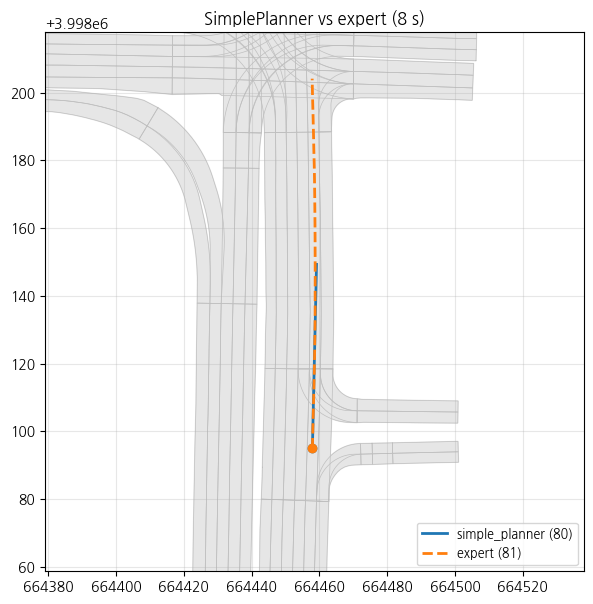

In [27]:
# SimplePlanner 로 80 스텝(8 초)을 실행하고 expert 궤적과 겹쳐 그린다.
sim = make_sim(scenario)                       # 위 SimulationSetup 구성과 동일하다
planner = SimplePlanner(horizon_seconds=20.0, sampling_time=0.25,
                        acceleration=[0.0, 0.0], max_velocity=5.0)
history = run_steps(sim, planner, n_steps=80, verbose=True)

plot_paths({"simple_planner": ego_xy(history), "expert": expert_xy(scenario, 80)},
           map_api=scenario.map_api, title="SimplePlanner vs expert (8 s)")
plt.show()


동일한 시나리오를 `IDMPlanner` 로 실행하여 비교한다. IDM 은 경로(roadblock)를 추종하면서
선행 차량과의 간격에 따라 속도를 결정하는 규칙 기반 planner 이다.


IDMPlanner could not find valid path to the target roadblock. Using longest route found instead
/home/user/miniconda3/envs/e2e_refinement/lib/python3.9/site-packages/shapely/linear.py:88: RuntimeWarning: invalid value encountered in line_locate_point
  return lib.line_locate_point(line, other)


  80 스텝, 4.5s


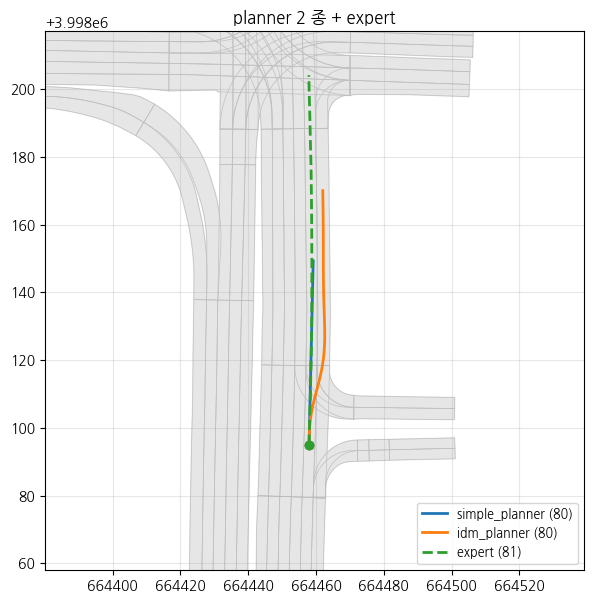

In [18]:
# 동일한 시나리오를 IDMPlanner 로 실행하여 두 planner 의 주행을 비교한다.
from nuplan.planning.simulation.planner.idm_planner import IDMPlanner

sim_idm = make_sim(scenario)
idm = IDMPlanner(target_velocity=10, min_gap_to_lead_agent=1.0, headway_time=1.5,
                 accel_max=1.0, decel_max=3.0, planned_trajectory_samples=16,
                 planned_trajectory_sample_interval=0.5, occupancy_map_radius=40)
history_idm = run_steps(sim_idm, idm, n_steps=80, verbose=True)

plot_paths({"simple_planner": ego_xy(history), "idm_planner": ego_xy(history_idm),
            "expert": expert_xy(scenario, 80)},
           map_api=scenario.map_api, title="planner 2 종 + expert")
plt.show()


**확인 사항** — `simple_planner` 는 차선을 이탈하고 `idm_planner` 는 차선을 추종한다.
같은 시나리오·같은 컨트롤러에서 planner 만 바꾼 결과이며, 이 차이가 다음 절에서 점수로 나타난다.


## 6. planner 교체 — config 기반 실행

지금까지는 객체를 직접 생성하였다. 동일한 작업을 `run_simulation.py` 의 **override 한 줄**로
지시할 수 있다. 실제 실습과 평가는 이 방식으로 수행한다. 채점과 집계가 함께 수행되기 때문이다.

```bash
python run_simulation.py +simulation=open_loop_boxes planner=simple_planner ...
```

### 실습에서 사용하는 planner

planner 는 매 스텝 `PlannerInput`(자차 상태 이력과 주변 물체 관측)을 받아 **8 초 앞까지의 계획
궤적**을 반환한다. 세 planner 는 이 궤적을 만드는 방식이 서로 다르다.

| planner | 계획 궤적을 만드는 방식 | 지도 | 주변 물체 |
|---|---|---|---|
| `simple_planner` | 현재 속도와 헤딩을 유지하는 직선 | 사용하지 않음 | 사용하지 않음 |
| `idm_planner` | 지도의 roadblock 경로를 추종하며, 선행 차량과의 간격에 따라 속도를 정한다 | 사용 | 사용 |
| `log_future_planner` | 로그에 기록된 자차의 미래 궤적을 그대로 반환한다 | 해당 없음 | 해당 없음 |

`log_future_planner` 는 실제 planner 가 아니라 **채점의 기준선**이다. Open-loop 는 로그와의
오차를 재므로 이 planner 의 점수는 정의상 1.000 이어야 하며, 그렇지 않다면 채점 경로에 문제가
있는 것이다.

먼저 **시나리오 하나**로 세 planner 를 돌려 교체 방법과 점수가 나오는 경로를 확인한다.
Open-loop 로 돌리므로 계획 궤적이 로그의 실제 궤적과 얼마나 닮았는지만 평가된다.
`simple_planner` 최하위, `idm_planner` 중간, `log_future_planner` 최상위를 예상할 수 있다.
**실행 이전에 예상 순위를 기록**하고 결과와 대조한다.


In [19]:
# 세 planner 를 시나리오 하나로 실행한다 (planner= 한 줄만 다르다).
PLANNERS = ["simple_planner", "idm_planner", "log_future_planner"]

for name in PLANNERS:
    run(f"source script/nuplan_env.sh && python run_simulation.py "
        f"+simulation=open_loop_boxes "
        f"planner={name} "
        f"scenario_builder=nuplan scenario_filter=practice_scenarios "
        f"scenario_filter.limit_total_scenarios=1 "
        f"worker=sequential "
        f"experiment_uid=practice1/single/{name}")


$ source script/nuplan_env.sh && python run_simulation.py +simulation=open_loop_boxes planner=simple_planner scenario_builder=nuplan scenario_filter=practice_scenarios scenario_filter.limit_total_scenarios=1 worker=sequential experiment_uid=practice1/single/simple_planner
------------------------------------------------------------------------------
Global seed set to 0
INFO:nuplan.planning.script.builders.main_callback_builder:Building MultiMainCallback...
INFO:nuplan.planning.script.builders.main_callback_builder:Building MultiMainCallback: 4...DONE!
2026-08-10 16:01:53,279 INFO {/home/user/E2E_Refinement_Practice/nuplan/planning/script/builders/worker_pool_builder.py:19}  Building WorkerPool...
2026-08-10 16:01:53,280 INFO {/home/user/E2E_Refinement_Practice/nuplan/planning/utils/multithreading/worker_pool.py:101}  Worker: Sequential
2026-08-10 16:01:53,280 INFO {/home/user/E2E_Refinement_Practice/nuplan/planning/utils/multithreading/worker_pool.py:102}  Number of nodes: 1
Number of

In [20]:
# 세 실행의 Open-loop 점수를 모아 비교한다.
SINGLE = REPO_ROOT / "data/exp/simulation/open_loop_boxes/practice1/single"
display(final_scores(SINGLE, columns=OPEN_METRICS).sort_values("final_score", ascending=False))


,run,final_score,planner_expert_average_l2_error_within_bound,planner_expert_final_l2_error_within_bound,planner_expert_average_heading_error_within_bound,planner_expert_final_heading_error_within_bound,planner_miss_rate_within_bound
1,log_future_planner,1.0,1.0,1.0,1.000000,1.000000,1.0
0,idm_planner,0.0,0.0,0.0,0.988435,0.986560,0.0
2,simple_planner,0.0,0.0,0.0,0.988198,0.983142,0.0


**확인 사항**

- `log_future_planner` 만 1.000 이고 나머지 둘은 **모두 0.000** 이다. 예상했던 순위
  (`log_future` > `idm` > `simple`)를 이 결과로는 확인할 수 없다.
- Open-loop 점수는 `planner_miss_rate_within_bound` 를 **곱셈 항**으로 쓴다. 계획 궤적이 허용
  오차를 벗어나면 그 시나리오는 0 이 되고, 얼마나 벗어났는지는 점수에 남지 않는다. 규칙 기반
  planner 둘 다 이 교차로에서 임계를 넘었으므로 나란히 0 이다.
- 즉 **시나리오 하나로는 planner 를 비교할 수 없다.** 8 절에서 시나리오를 5개로 늘린다.


## 7. 챌린지 프리셋의 구조

6 절에서 사용한 `+simulation=open_loop_boxes` 가 실제로 무엇을 바꾸는지 확인하고, 나머지 두
프리셋과 비교한다. 프리셋은 yaml 한 개를 읽어 **여러 그룹을 한꺼번에 override** 한다.


In [28]:
# 세 챌린지 프리셋 yaml 의 내용을 직접 확인한다.
run("cat nuplan/planning/script/experiments/simulation/open_loop_boxes.yaml "
        "nuplan/planning/script/experiments/simulation/closed_loop_nonreactive_agents.yaml "
        "nuplan/planning/script/experiments/simulation/closed_loop_reactive_agents.yaml ")


$ cat nuplan/planning/script/experiments/simulation/open_loop_boxes.yaml nuplan/planning/script/experiments/simulation/closed_loop_nonreactive_agents.yaml nuplan/planning/script/experiments/simulation/closed_loop_reactive_agents.yaml 
------------------------------------------------------------------------------
# @package _global_
job_name: open_loop_boxes

defaults:
  - override /observation: box_observation
  - override /ego_controller: log_play_back_controller
  - override /planner: log_future_planner
  - override /simulation_metric: simulation_open_loop_boxes
  - override /metric_aggregator:
      - open_loop_boxes_weighted_average
# @package _global_
job_name: closed_loop_nonreactive_agents

defaults:
  - override /observation: box_observation
  - override /ego_controller: two_stage_controller
  - override /planner: simple_planner
  - override /simulation_metric: simulation_closed_loop_nonreactive_agents
  - override /metric_aggregator:
      - closed_loop_nonreactive_agents_weig

0

| 프리셋 | observation | ego_controller | 의미 |
|---|---|---|---|
| `closed_loop_nonreactive_agents` | `box_observation` | `two_stage_controller` | ego 는 자신의 궤적으로 주행, 주변은 로그 재생 |
| `closed_loop_reactive_agents` | `idm_agents_observation` | `two_stage_controller` | 주변 물체가 ego 에 반응 |
| `open_loop_boxes` | `box_observation` | `log_play_back_controller` | **ego 도 로그 재생** |

차이의 본질은 두 개의 축으로 정리된다.

1. **ego 가 자신의 궤적으로 주행하는가** — Closed-loop / Open-loop
2. **주변 물체가 ego 에 반응하는가** — reactive / non-reactive

본 실습은 이 중 **Open-loop 만** 다룬다. Open-loop 는 계획 궤적 하나만 있으면 채점할 수 있어
프레임워크를 확인하기에 적합하고, 실행 시간도 짧다.

Closed-loop 는 궤적이 실제로 실행되므로 추종 오차(4 절)와 매 스텝의 재계획이 함께 쌓인다. 그 결과
같은 planner 라도 Open-loop 와 전혀 다른 점수가 나오는데, 이 비교는 **실습 2** 에서 ML planner 로
다룬다.


**확인 사항**

- 세 프리셋에서 실제로 바뀌는 것은 `observation` · `ego_controller` · `simulation_metric` ·
  `metric_aggregator` 네 그룹뿐이다. 시나리오도 planner 도 프리셋이 정하지 않는다.
- `open_loop_boxes` 는 `planner` 를 `log_future_planner` 로 덮어쓴다. 그래서 6 절과 8 절의
  명령에서 `planner=` 가 **`+simulation=` 뒤에** 놓여 있다. 순서를 바꾸면 프리셋이 이겨서
  지정한 planner 가 무시된다.
- Open-loop 는 `ego_controller` 가 `log_play_back_controller` 이므로 planner 를 무엇으로 바꾸어도
  자차의 주행 자체는 로그와 동일하다. 달라지는 것은 채점 대상인 계획 궤적뿐이다.


## 8. 정식 Open-loop 평가 — 시나리오 5개

6 절에서 시나리오 하나로는 순위를 가릴 수 없음을 확인했다. `practice_scenarios` 의 시나리오
**5개 전부**를 세 planner 로 평가한다.

시나리오가 5개이므로 ray 로 병렬 실행한다. 규칙 기반 planner 는 GPU 를 쓰지 않으므로
`number_of_gpus_allocated_per_simulation=0` 으로 두어 CPU 만으로 5개를 동시에 돌린다.

> planner 당 약 1 분, 전체 3 분 내외이다. ray 는 워커별 로그를 한데 섞어 출력하므로
> 진행 상황을 따라가기 어렵다. 원인을 찾아야 할 때는 `worker=sequential` 로 바꾼다.


In [29]:
# 시나리오 5개를 세 planner 로 평가한다. ray 워커 5개로 동시에 돌린다.
for name in PLANNERS:
    run(f"source script/nuplan_env.sh && python run_simulation.py "
        f"+simulation=open_loop_boxes "
        f"planner={name} "
        f"scenario_builder=nuplan scenario_filter=practice_scenarios "
        f"worker=ray_distributed worker.threads_per_node=5 "
        f"distributed_mode=SINGLE_NODE number_of_gpus_allocated_per_simulation=0 "
        f"experiment_uid=practice1/open_loop/{name}")


$ source script/nuplan_env.sh && python run_simulation.py +simulation=open_loop_boxes planner=simple_planner scenario_builder=nuplan scenario_filter=practice_scenarios worker=ray_distributed worker.threads_per_node=5 distributed_mode=SINGLE_NODE number_of_gpus_allocated_per_simulation=0 experiment_uid=practice1/open_loop/simple_planner
------------------------------------------------------------------------------
Global seed set to 0
INFO:nuplan.planning.script.builders.main_callback_builder:Building MultiMainCallback...
INFO:nuplan.planning.script.builders.main_callback_builder:Building MultiMainCallback: 4...DONE!
2026-08-10 16:18:09,192 INFO {/home/user/E2E_Refinement_Practice/nuplan/planning/script/builders/worker_pool_builder.py:19}  Building WorkerPool...
2026-08-10 16:18:09,225 INFO {/home/user/E2E_Refinement_Practice/nuplan/planning/utils/multithreading/worker_ray.py:78}  Starting ray local!
2026-08-10 16:18:10,854	INFO worker.py:2012 -- Started a local Ray instance.
/home/user

In [23]:
# 세 planner 의 Open-loop 점수와 세부 지표를 비교한다.
OPEN = REPO_ROOT / "data/exp/simulation/open_loop_boxes/practice1/open_loop"
display(final_scores(OPEN, columns=OPEN_METRICS).sort_values("final_score", ascending=False))


,run,final_score,planner_expert_average_l2_error_within_bound,planner_expert_final_l2_error_within_bound,planner_expert_average_heading_error_within_bound,planner_expert_final_heading_error_within_bound,planner_miss_rate_within_bound
1,log_future_planner,1.000000,1.000000,1.000000,1.000000,1.000000,1.0
2,simple_planner,0.158745,0.202988,0.060287,0.756267,0.648811,0.2
0,idm_planner,0.000000,0.003631,0.000000,0.847268,0.799184,0.0


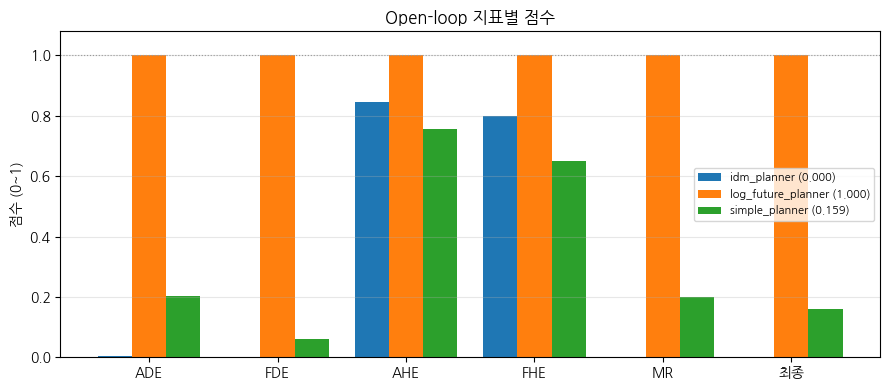

In [24]:
# 표의 다섯 지표를 planner 별로 막대로 비교한다.
plot_open_loop_scores(final_scores(OPEN, columns=OPEN_METRICS))
plt.tight_layout(); plt.show()


Open-loop 지표는 다섯 개이다. 오차는 계획 궤적과 로그 궤적을 **1 초 간격으로 짝지어** 재고,
**3 · 5 · 8 초** 세 지평에서 집계한 뒤 그 평균을 점수로 환산한다.

앞의 네 지표는 0/1 이 아니라 **임계로 정규화한 [0, 1] 연속값**이다.

$$s = \max\left(0,\; 1 - \frac{\text{오차}}{\text{임계}}\right)$$

0/1 인 것은 곱셈 항인 `miss_rate` 하나뿐이다.

| 지표 | 약칭 | 재는 것 | 임계 |
|---|---|---|---|
| `average_l2_error` | **ADE** | 지평까지의 표본마다 두 궤적의 거리 오차를 재어 평균한 값 | 8 m |
| `final_l2_error` | **FDE** | 지평 끝 한 점에서의 거리 오차 | 8 m |
| `average_heading_error` | **AHE** | 같은 표본에서의 헤딩 오차 평균 | 0.8 rad |
| `final_heading_error` | **FHE** | 지평 끝에서의 헤딩 오차 | 0.8 rad |
| `miss_rate` | **MR** | 지평별 최대 오차가 허용치(3초 6 m · 5초 8 m · 8초 16 m)를 넘은 표본 비율 | **세 지평 전부** 0.3 이하여야 통과, **곱셈 항** |

ADE 는 8 초 내내 얼마나 붙어 갔는지를, FDE 는 끝에서 얼마나 벌어졌는지를 본다. 같은 ADE 라도
FDE 가 크면 후반부에 갈라진 궤적이다. MR 은 곱셈 항이라 0.3 을 넘는 순간 나머지 네 지표와
무관하게 최종 점수가 0 이 된다.

실제로 몇 미터 틀렸는지는 `metrics/` 아래 원시 통계에만 있다. 3 · 5 · 8 초 지평의 값을 확인한다.


네 지표의 감점 곡선과 `miss_rate` 게이트를 함께 그린다. 가중치는 헤딩 쪽이 2 로 더 크다.


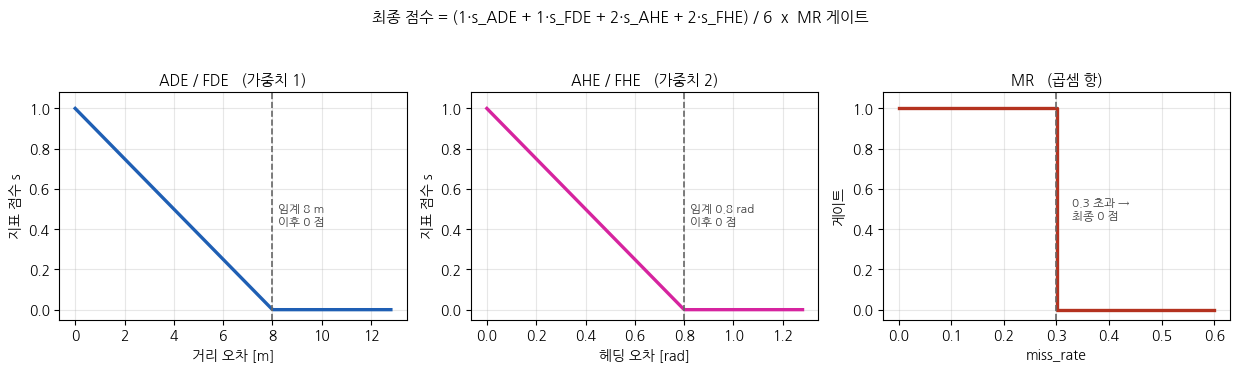

In [25]:
# Open-loop 점수 산식 — 감점 곡선 2개와 곱셈 게이트 1개.
plot_open_loop_score_formula()
plt.tight_layout(); plt.show()


#### 빈칸 ② — Open-loop 최종 점수

위 그래프의 산식을 그대로 코드로 옮긴다. 네 지표를 각각 점수로 바꾸고, 가중평균한 뒤
`miss_rate` 게이트를 곱한다.

$$
s_i = \max\left(0,\ 1 - \frac{e_i}{\tau_i}\right), \qquad
\text{score} = \frac{\sum_i w_i s_i}{\sum_i w_i} \times \mathbb{1}[\,\text{MR} \le 0.3\,]
$$

| 지표 | 임계 $\tau$ | 가중치 $w$ |
|---|---|---|
| ADE | 8 m | 1 |
| FDE | 8 m | 1 |
| AHE | 0.8 rad | 2 |
| FHE | 0.8 rad | 2 |

임계를 넘으면 음수가 아니라 **0 으로 잘린다**. `miss_rate` 는 0.3 **이하**가 통과이다.


In [ ]:
def open_loop_score(ade, fde, ahe, fhe, miss_rate):
    """Open-loop 최종 점수. ade/fde 는 m, ahe/fhe 는 rad."""
    # 예시 — 임계로 나누고 1 에서 뺀 뒤 음수는 0 으로 자른다.
    s_ade = max(0.0, 1.0 - ade / 8.0)

    # [TODO ①] 목적: 네 지표를 같은 방식으로 [0,1] 점수로 환산한다.
    #                단위가 달라도(거리 m, 헤딩 rad) 임계로 나누면 비교 가능해진다.
    #          채울 것: FDE 점수 s_fde   (임계 8 m)
    #          수식: s = max(0, 1 - 오차/임계)
    #          임계의 출처는 아래 yaml 들이다:
    #          nuplan/planning/script/config/common/simulation_metric/high_level/
    #              planner_expert_*_error_within_bound_statistics.yaml
    s_fde = max(0,0, 1.0 - fde/8.0)

    # [TODO ②] 채울 것: AHE 점수 s_ahe   (임계 0.8 rad — 거리와 임계가 다르다)
    #          수식: s = max(0, 1 - 오차/임계)
    s_ahe = np.max(0,1 - ahe/0.8)

    # [TODO ③] 채울 것: FHE 점수 s_fhe   (임계 0.8 rad)
    #          수식: s = max(0, 1 - 오차/임계)
    s_fhe = np.max(0,1 - fhe/0.8)

    # [TODO ④] 목적: 지표마다 중요도가 다르다. 헤딩 오차는 거리 오차보다 2 배로 본다.
    #          채울 것: AHE, FHE 의 가중치
    #          수식: ADE 1, FDE 1, AHE 2, FHE 2
    #          값의 출처는 아래 yaml 의 metric_weights 이다:
    #          nuplan/planning/script/config/simulation/metric_aggregator/
    #              open_loop_boxes_weighted_average.yaml
    w_ade = 1.0
    w_fde = 1.0
    w_ahe = 2.0
    w_fhe = 2.0

    # [TODO ⑤] 목적: 네 점수를 하나로 합친다. 단순 평균이 아니라 가중평균이다.
    #          채울 것: 분자(가중합)와 분모(가중치 합)를 직접 더한다
    #          수식: weighted = (w1*s1 + w2*s2 + w3*s3 + w4*s4) / (w1 + w2 + w3 + w4)
    numerator = (
        w_ade * s_ade
        + w_fde * s_fde
        + w_ahe * s_ahe      # AHE
        + w_fhe * s_fhe      # FHE
    )
    denominator = (
        w_ade
        + w_fde
        + w_ahe      # AHE
        + w_fhe      # FHE
    )
    weighted = numerator / denominator

    # [TODO ⑥] 목적: 곱셈 항의 성격을 확인한다. 이 값이 0 이면 위 네 지표가 아무리
    #                좋아도 최종 점수는 0 이다.
    #          채울 것: miss_rate 게이트 gate  (1.0 또는 0.0)
    #          수식: gate = 1 if miss_rate <= 0.3 else 0
    gate = 1 if miss_rate <= 0.3 else 0

    return weighted * gate


check_open_loop_score(open_loop_score)


❌ open_loop_score — 9/9개 실패
   · 오차 0, MR 0        → 만점
       기대 1.0
       실제 "<TypeError: 'float' object cannot be interpreted as an integer>"   ← TODO 를 채우지 않았습니다
   · 전부 임계값, MR 0   → 0 점
       기대 0.0
       실제 "<TypeError: 'float' object cannot be interpreted as an integer>"   ← TODO 를 채우지 않았습니다
   · 전부 임계 절반      → 0.5
       기대 0.5
       실제 "<TypeError: 'float' object cannot be interpreted as an integer>"   ← TODO 를 채우지 않았습니다
   · 임계 초과는 음수가 아니라 0 으로 잘린다
       기대 0.8333
       실제 "<TypeError: 'float' object cannot be interpreted as an integer>"   ← TODO 를 채우지 않았습니다
   힌트: s = max(0, 1 - 오차/임계) 를 네 지표에 적용하고, 가중치 ADE 1 · FDE 1 · AHE 2 · FHE 2 로 가중평균한 뒤 miss_rate 게이트를 곱한다.


False

채운 함수를 **실제 런의 원시 오차**에 적용해 nuPlan 이 계산한 점수와 맞는지 본다.

`open_loop_inputs()` 가 시나리오별 입력을 뽑아 준다. `miss_rate` 는 지평별 miss rate 의
**최댓값**이다 — 공식 게이트가 `all(지평별 miss rate <= 0.3)` 이라 최댓값 하나로 같은 판정이 된다.


In [ ]:
# 시나리오별 원시 오차를 내 함수에 넣고 공식 점수와 대조한다.
ol = open_loop_inputs(OPEN)
ol["mine"] = [open_loop_score(r.ade, r.fde, r.ahe, r.fhe, r.miss_rate)
              for r in ol.itertuples()]
ol["차이"] = (ol["mine"] - ol["official"]).abs()
display(ol.round(4))
print("최대 차이:", f"{ol['차이'].max():.2e}",
      "| 시나리오 평균이 런 점수:", ol.groupby('planner')['mine'].mean().round(4).to_dict())


In [ ]:
# 지평(3·5·8초)별 원시 오차값을 확인한다 — 집계표에는 없는 실제 오차(m)이다.
display(openloop_horizon_table(OPEN))


In [ ]:
# 지평이 늘어날 때 원시 오차가 어떻게 커지는지 그린다.
plot_open_loop_horizons(openloop_horizon_table(OPEN))
plt.tight_layout(); plt.show()


### 시각화 — Open-loop 가 재는 것을 직접 그린다

실습 2 에서는 매 프레임에 점수가 새겨진 **영상**이 나온다. 본 절의 planner 는 devkit 내장
구현이라 프레임을 만들지 않으므로 영상이 없다. 대신 Open-loop 지표가 재는 대상을 그대로 그린다.

**계획 궤적과 로그 궤적을 한 축에 점으로 겹쳐 놓는 것**이 Open-loop 의 정의다. 두 점열을
1 초 간격으로 짝지어 거리를 재면 그것이 ADE·FDE 이다. planner 를 한 스텝만 호출하여 확인한다.


In [ ]:
# 세 planner 를 한 스텝만 호출하여 계획 궤적을 얻고, 같은 구간의 로그 궤적과 겹쳐 그린다.
from nuplan.planning.simulation.planner.idm_planner import IDMPlanner
from nuplan.planning.simulation.planner.log_future_planner import LogFuturePlanner

# 인자는 devkit 의 planner yaml 기본값과 동일하다 — 위 표의 점수를 만든 그 설정이다.
one_step_planners = {
    "simple_planner": SimplePlanner(horizon_seconds=10.0, sampling_time=0.25,
                                    acceleration=[0.0, 0.0], max_velocity=5.0,
                                    steering_angle=0.0),
    "idm_planner": IDMPlanner(target_velocity=10, min_gap_to_lead_agent=1.0, headway_time=1.5,
                              accel_max=1.0, decel_max=3.0, planned_trajectory_samples=16,
                              planned_trajectory_sample_interval=0.5, occupancy_map_radius=40),
    "log_future_planner": LogFuturePlanner(scenario, num_poses=16, future_time_horizon=8.0),
}
plans, log = plan_vs_log(scenario, one_step_planners, iteration=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
plot_plan_vs_log(plans, log, map_api=scenario.map_api, ax=axes[0])
plot_plan_error(plans, log, ax=axes[1])
plt.tight_layout(); plt.show()


**확인 사항**

- **예상했던 순위가 성립하지 않는다.** `log_future` 1.000 은 예상대로지만, `simple_planner`
  0.159 가 `idm_planner` 0.000 보다 높다. 경로를 추종하는 `idm_planner` 가 직진만 하는
  `simple_planner` 에 뒤진다.
- 원인은 **`miss_rate` 가 시나리오별 0/1 게이트**라는 점이다. `simple_planner` 는 5 개 중 1 개
  (`d13124fa`, 평균 ADE 2.53 m)에서 게이트를 통과해 0.2 를 받았고, `idm_planner` 는 5 개 전부
  실패해 0.0 이다. 곱셈 항이므로 나머지 네 지표가 무엇이든 최종 점수가 결정된다.
- **평균 오차의 크기와 최종 점수의 순위는 일치하지 않는다.** `idm_planner` 의 평균 ADE 는
  `56cdd36746c85788` 에서 57.9 m 로 매우 크지만, 나머지 네 시나리오에서는 7.9~8.7 m 로
  `simple_planner` 와 비슷하다. 임계 8 m 를 아슬아슬하게 넘겨 전부 실패한 것이다.
- `log_future_planner` 는 1.000 이고 원시 오차도 정확히 0 이다. 로그의 미래를 그대로 냈으므로
  당연하며, Open-loop 에는 추종 오차가 개입하지 않는다. 4 절에서 확인한 추종 오차는 궤적을
  **실행할 때만** 나타나고 Open-loop 는 실행하지 않는다.
- 8 초 지평의 FDE 가 3 초보다 훨씬 크다. 멀리 볼수록 예측이 어긋난다.


## 9. 정리

시뮬레이션의 한 스텝은 다음 세 줄로 정의되며,

```python
planner_input = simulation.get_planner_input()
trajectory    = planner.compute_trajectory(planner_input)
simulation.propagate(trajectory)
```

교체 가능한 구성 요소는 네 개이다.

| 구성 요소 | 본 노트북에서 확인한 것 | 실습 2 에서 |
|---|---|---|
| planner | simple / idm / log_future | **ML planner 를 장착한다** |
| ego_controller | two_stage(LQR + Kinematic bicycle), perfect_tracking, log_play_back | 변경하지 않는다 (비교 조건 유지) |
| observation | box_observation (로그 재생) | 변경하지 않는다 |
| simulation_time_controller | step | 변경하지 않는다 |

정리하면 다음 세 가지이다.

1. **planner 는 `SimulationSetup` 외부에 위치한다.** 시뮬레이터는 궤적을 입력받아 상태를 생성한다.
2. **궤적을 제공하더라도 차량은 이를 그대로 추종하지 못한다.** 추종 오차는 planner 를 교체하여도
   잔존한다.
3. **점수를 비교하려면 나머지 세 구성 요소가 동일해야 한다.** planner 만 교체한 실행 간에만
   비교가 성립한다.

---

## Open-loop 평가의 한계

8 절에서 얻은 점수는 **계획 궤적이 로그와 얼마나 닮았는지**만을 나타낸다. 이 방식에는
원리적인 한계가 있으며, 본 노트북에서 그 근거를 이미 확인하였다.

| 한계 | 본 노트북에서 확인한 근거 |
|---|---|
| **궤적을 실행하지 않는다** | 6·8 절은 `log_play_back_controller` 를 쓴다. 자차는 로그를 재생하므로 4 절에서 측정한 추종 오차가 점수에 전혀 반영되지 않는다 |
| **오차가 누적되지 않는다** | 매 프레임 자차가 로그 위에 놓인 상태에서 새로 계획한다. 한 번 크게 어긋나도 다음 프레임은 정상 위치에서 시작한다 |
| **안전을 재지 않는다** | 지표 다섯 개가 전부 로그와의 오차다. 충돌·주행가능영역 이탈·역주행은 측정 대상이 아니다 |
| **사람과 다른 주행을 감점한다** | 로그가 유일한 정답이다. 더 안전하게 주행하더라도 로그와 다르면 오차로 계산된다 |

즉 Open-loop 점수가 높다는 것은 **"해당 시점에서 사람과 비슷하게 계획했다"** 는 의미이며,
**"이 planner 로 주행해도 안전하다"** 는 의미가 아니다.

## Closed-loop 평가가 필요한 이유

Open-loop 의 한계는 모두 **궤적을 실행하지 않는다**는 한 가지 원인에서 나온다.
`ego_controller` 를 `two_stage_controller` 로 바꾸면 1 절의 세 번째 줄이 살아난다.

```
simulation.propagate(trajectory)     # ← 계획한 궤적이 다음 상태를 만든다
```

이 한 줄이 바뀌면서 세 가지가 함께 따라온다.

1. **추종 오차가 개입한다.** 4 절에서 측정한 오차가 실제 자차 위치에 반영된다.
2. **오차가 누적된다.** 한 번 차선을 벗어나면 벗어난 자리에서 다시 계획해야 한다.
   7 절에서 확인한 Open-loop 와 Closed-loop 의 구분이 바로 이 지점이다.
3. **주변 물체와의 관계가 성립한다.** 자차가 로그를 벗어나 움직이므로 충돌·근접이

   실제로 발생할 수 있고, 그래서 안전 지표를 측정할 수 있다.

그래서 Closed-loop 지표는 성격이 다르다. 로그와의 유사도 대신 **충돌·주행가능영역·역주행·진행률**
같은 규칙 위반을 보며, 그중 넷은 **곱셈 항**이어서 한 번의 위반이 나머지 점수와 무관하게 최종
점수를 0 으로 만든다.

**두 점수는 서로 비교할 수 없다.** 재는 대상이 다르기 때문이다. Open-loop 에서 좋은 planner 가
Closed-loop 에서 0 점을 받는 일이 실제로 발생하며, 실습 2 에서 같은 planner·같은 시나리오로
그 경우를 확인한다.

### 다음 — 실습 2

planner 위치에 **ML planner**(PLUTO)를 장착하고, 동일한 시나리오를 **Open-loop 와 Closed-loop
양쪽으로** 평가한다. 본 노트북에서 확인한 네 구성 요소 중 **planner 만 교체**하고 나머지는 그대로
둔다. 그래야 점수 차이를 planner 의 차이로 귀속시킬 수 있다(6 절 확인 사항 참조).

Closed-loop 는 자차가 실제로 주행하므로 **매 프레임을 그림으로 남길 수 있다.** 실습 2 의 산출물이
스텝별 점수와 위반 사유가 새겨진 영상인 이유다.

MPC 를 이용한 궤적 후처리는 실습 3 에서 다룬다.
